<a href="https://colab.research.google.com/github/u9828057/WM811K-Wafer-Map-Analysis/blob/main/notebooks/01_WM811K_Data_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WM-811K Data Overview

## Prototype v0.1

This notebook performs the initial exploration of the WM-811K wafer map dataset, including: data loading, structural inspection, failure type distribution, and wafer map visualization.

## 1. Kaggle Dataset Setup

Configure Kaggle authentication in Google Colab, install the Kaggle CLI,
search for WM-811K dataset, and download it to the Colab runtime.

In [5]:
import os
from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

!pip install -q --upgrade kaggle

!kaggle --version

!kaggle datasets list -s "wm811k wafer map"

!kaggle datasets download -d qingyi/wm811k-wafer-map

!ls -lh

print(os.listdir("/content"))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.4 MB/s eta 0:00:00
Kaggle CLI 2.2.4
ref                                                     title                                         size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  --------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
muhammedjunayed/wm811k-silicon-wafer-map-dataset-image  WM811k Silicon Wafer Map Dataset Image     1006403  2024-12-20 12:13:35.537000           1633         14  0.875            
iamrajanjha/wm811kwafermapimages                        wm811k-wafer-map-images                 1141460846  2020-07-05 07:39:59.210000            620          8  0.1875           
qingyi/wm811k-wafer-map                                 WM-811K wafer map                        156686283  2018-02-26 05:44:18.930000          23753        149  0.5              
man

## 2. Dataset Extraction

Extract the downloaded WM-811K dataset into a separate directory for subsequent data loading and analysis.

In [6]:
!unzip -o wm811k-wafer-map.zip -d wm811k_data

# -o: overwrite existing files;
# -d: specify the extraction directory

Archive:  wm811k-wafer-map.zip
  inflating: wm811k_data/LSWMD.pkl   


## 3. Dataset File Inspection
Locate the `LSWMD.pkl` file in the extracted WM-811K dataset directory before loading it with Pandas.

In [7]:
!find wm811k_data -name "LSWMD.pkl"

wm811k_data/LSWMD.pkl


## 4. Dataset Loading

Load the WM-811K Pickle dataset into Pandas and verify that the loaded object is a DataFrame.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "wm811k_data/LSWMD.pkl"
df_wafer = pd.read_pickle(file_path)

type(df_wafer)

pandas.core.frame.DataFrame

## 5. Dataset Structure

Inspect the dimensions, column names, sample records, and data type of the WM-811K DataFrame.

>Note: `trianTestLabel` is the original column name provided by the dataset and is preserved at this stage.

### 5.1 Dataset Dimensions

Inspect the number of rows and columns in the dataset.

In [9]:
df_wafer.shape


(811457, 6)

### 5.2 Column Names
Inspect the column names to identify information stored in the dataset.

In [10]:
df_wafer.columns

Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

### 5.3 Data Preview

Preview the first few rows of the dataset to inspect the actual data stored in each column.

In [11]:
df_wafer.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


### 5.4 DataFrame Information

Inspect the DataFrame structure, non-null counts, data types and memory usage of each column.

In [12]:
df_wafer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


### Observation

- The dataset contains 811,457 rows and 6 columns.
- All columns contain 811,457 non-null entries, so no conventional missing values are detected at the DataFrame level.
- `dieSize` and `waferIndex` are stored as `float64`.
- `waferMap`, `lotName`, `trianTestLabel`, and `failureType` are stored as `object`.
- Since `object` columns may contain nested structures such as NumPy arrays, their actual element types should be inspected before data cleaning.


## 6. Object Structure Inspection

Inspect the actual Python and NumPy object types stored inside the object-type columns of the first wafer record.

In [13]:
print(f"waferMap: {type(df_wafer.loc[0, 'waferMap'])}")
print(f"lotName: {type(df_wafer.loc[0, 'lotName'])}")
print(f"trianTestLabel: {type(df_wafer.loc[0, 'trianTestLabel'])}")
print(f"failureType: {type(df_wafer.loc[0, 'failureType'])}")

waferMap: <class 'numpy.ndarray'>
lotName: <class 'numpy.str_'>
trianTestLabel: <class 'numpy.ndarray'>
failureType: <class 'numpy.ndarray'>


### 6.1 Nested Object Structure
Inspect the shape and contents of the NumPy arrays stored in the first wafer record.

In [14]:
print(f"waferMap shape: {df_wafer.loc[0, 'waferMap'].shape}")

# Show the unique values contained in the first wafer map
print(f"waferMap values: {np.unique(df_wafer.loc[0, 'waferMap'])}")

print(f"\ntrianTestLabel shape: {df_wafer.loc[0, 'trianTestLabel'].shape}")
print(f"failureType shape: {df_wafer.loc[0, 'failureType'].shape}")

print(f"\ntrianTestLabel: {df_wafer.loc[0, 'trianTestLabel']}")
print(f"failureType: {df_wafer.loc[0, 'failureType']}")

waferMap shape: (45, 48)
waferMap values: [0 1 2]

trianTestLabel shape: (1, 1)
failureType shape: (1, 1)

trianTestLabel: [['Training']]
failureType: [['none']]


## 7. Failure Label Inspection
The original `failureType` and `trianTestLabel` columns contain nested NumPy arrays rather than simple strings.

Extract the label values into simplified columns while preserving the original dataset columns.

In [15]:
def extract_label(value):
  if isinstance(value, np.ndarray):
    if value.size == 0:
      return "unlabeled"

    # Flatten the array and extract its first label
    return str(value.ravel()[0])

  if pd.isna(value):
    return "unlabeled"

  return str(value)


# Preserve the original DataFrame and create a separate analysis copy
df_analysis = df_wafer.copy()

df_analysis["failureType_clean"] = df_analysis["failureType"].apply(extract_label)
df_analysis["trainTestLabel_clean"] = df_analysis["trianTestLabel"].apply(extract_label)

### 7.1 Extracted Labels

Inspect the frequency distribution of the extracted failure and train/test labels.

In [16]:
# Count the occurrences of each cleaned label
print("Failure Type Labels:")
print(df_analysis["failureType_clean"].value_counts())

print("\nTrain/Test Labels:")
print(df_analysis["trainTestLabel_clean"].value_counts())

Failure Type Labels:
failureType_clean
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Train/Test Labels:
trainTestLabel_clean
unlabeled    638507
Test         118595
Training      54355
Name: count, dtype: int64


## 8. Label Availability

Distinguish between wafers with failure labels, wafers explicitly labeled as `none`, and wafers without failure labels.

In [17]:
total_wafers = len(df_analysis)

unlabeled_wafers = (df_analysis["failureType_clean"] == "unlabeled").sum()

none_wafers = (df_analysis["failureType_clean"] == "none").sum()

# Exclude no-failure and unlabeled wafers
failure_wafers = (~df_analysis["failureType_clean"].isin(["unlabeled", "none"])).sum()

label_summary = pd.DataFrame({
    "Category": [
        "Total Wafers",
        "Unlabeled Wafers",
        "No-Failure Wafers",
        "Failure-Pattern Wafers"
    ],
    "Count": [
        total_wafers,
        unlabeled_wafers,
        none_wafers,
        failure_wafers
    ]
})

display(label_summary)

,Category,Count
0,Total Wafers,811457
1,Unlabeled Wafers,638507
2,No-Failure Wafers,147431
3,Failure-Pattern Wafers,25519


## 9. Failure Type Distribution

Analysis the distribution of the labeled failure patterns in the WM-811K dataset.

The `none` and `unlabeled` categories are excluded from the defect-pattern distribution so that the actual failure classes can be compared more clearly.

In [18]:
defect_mask = ~df_analysis["failureType_clean"].isin(
    ["none", "unlabeled"]
)

failure_counts = df_analysis.loc[defect_mask, "failureType_clean"].value_counts()

display(failure_counts)

,count
failureType_clean,
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


### Failure Type Distribution Visualization

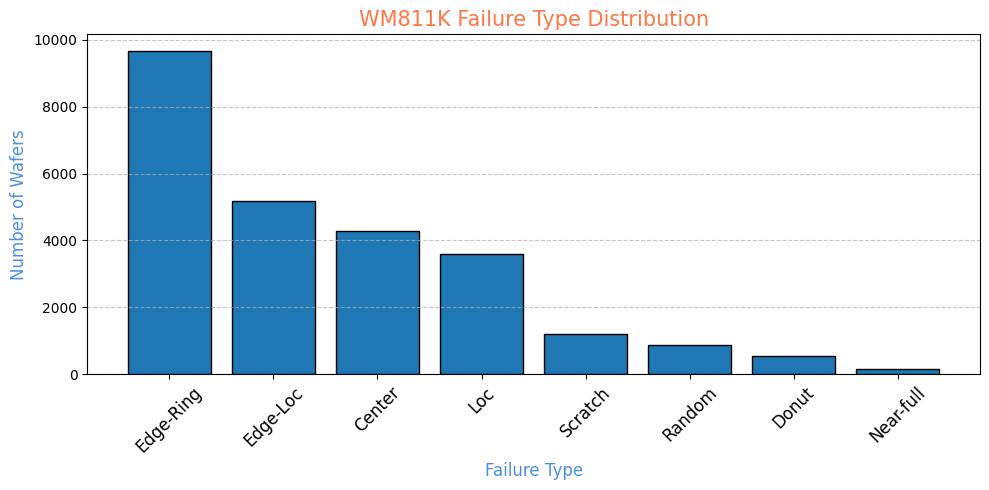

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(failure_counts.index, failure_counts.values, edgecolor="k")

plt.title("WM811K Failure Type Distribution", fontsize=15, color="#FF7744")
plt.xlabel("Failure Type", fontsize=12, c="#4A90E2")
plt.ylabel("Number of Wafers", fontsize=12, c="#4A90E2")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()

plt.show()



## 10. Wafer Map Visualization

Visualize an individual wafer map to vertify that two-dimensional wafer data can be correctly interpreted and displayed using Matplotlib.

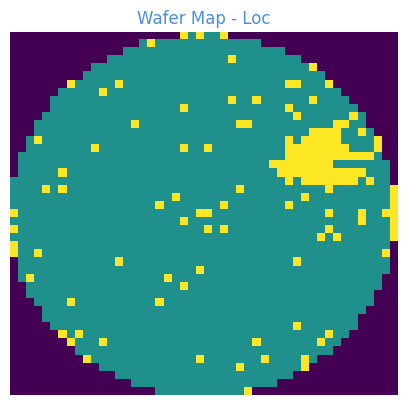

In [24]:
# Select the index of the first wafer with a failure pattern
sample_index = df_analysis[defect_mask].index[0]

sample_map = df_analysis.loc[sample_index, "waferMap"]
sample_label = df_analysis.loc[sample_index, "failureType_clean"]

plt.figure(figsize=(5, 5))

# Preserve the disctete die-map appearance without smoothing
plt.imshow(sample_map, interpolation="nearest")

plt.title(f"Wafer Map - {sample_label}", c="#4A90E2")
plt.axis("off")

plt.show()

## 11. Representative Failure Patterns

Visualize representative wafer maps from the major failure categories  to compare their spatial defect patterns.

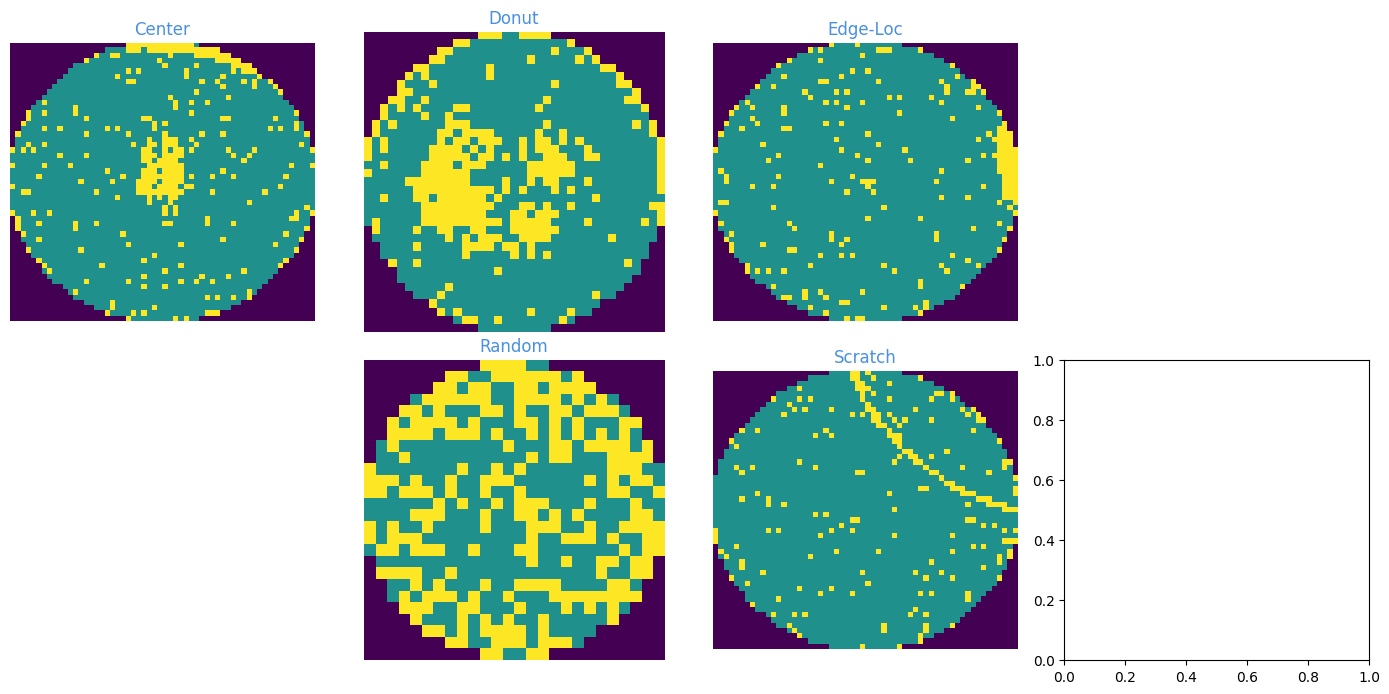

In [35]:
failure_patterns = [
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring"
    "Loc",
    "Near-Full",
    "Random",
    "Scratch"
]

# Create a 2x4 subplot grid for the eight failure patterns
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Flattern the 2D axes array for sequential iteration
axes = axes.flatten()

for ax, failure_type in zip(axes, failure_patterns):

  sample = df_analysis[df_analysis["failureType_clean"] == failure_type]

  if not sample.empty:
    # Select the first wafer sample of the current fialure type
    wafer_map = sample.iloc[0]["waferMap"]

    ax.imshow(wafer_map, interpolation="nearest")
    ax.set_title(failure_type, c="#4A90E2")

  ax.axis("off")

plt.tight_layout()
plt.show()